In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("house_prices_dataset.csv")

print(df.head())
print(df.info())

   square_feet  num_rooms  age  distance_to_city(km)          price
0  2248.357077          3   92             22.997972  200374.090410
1  1930.867849          2   22             13.984254  268784.847337
2  2323.844269          6   33             21.500945  315020.857676
3  2761.514928          3   63             10.343638  355111.468459
4  1882.923313          7   54             25.485200  234197.123903
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB
None


In [4]:
#Handle Missing Values

df = df.dropna()

In [8]:
#Select Features and Target

X = df[['square_feet', 'num_rooms', 'age', 'distance_to_city(km)']]
y = df['price']

In [10]:
numeric_features = ['square_feet', 'num_rooms', 'age']

In [11]:
categorical_features = ['distance_to_city(km)']

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['square_feet', 'num_rooms',
                                                   'age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['distance_to_city(km)'])])),
                ('regressor', LinearRegression())])

In [15]:
#predictions

y_pred = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 39494.4961324482


In [17]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 46782.642512783474


In [18]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.7738216627371444


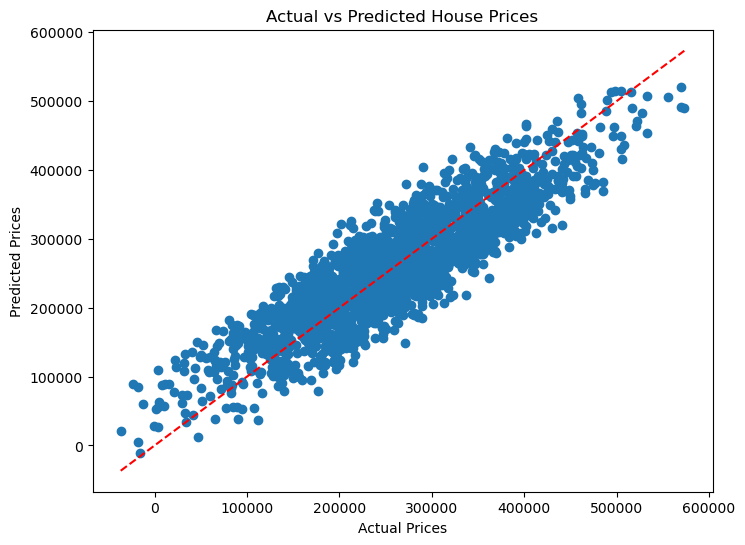

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()